<a href="https://colab.research.google.com/github/Rajeraghav/AI-Engineer-Journey/blob/main/Day04/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Mall_Customers.csv to Mall_Customers.csv
First 5 Records
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape
(200, 5)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int6

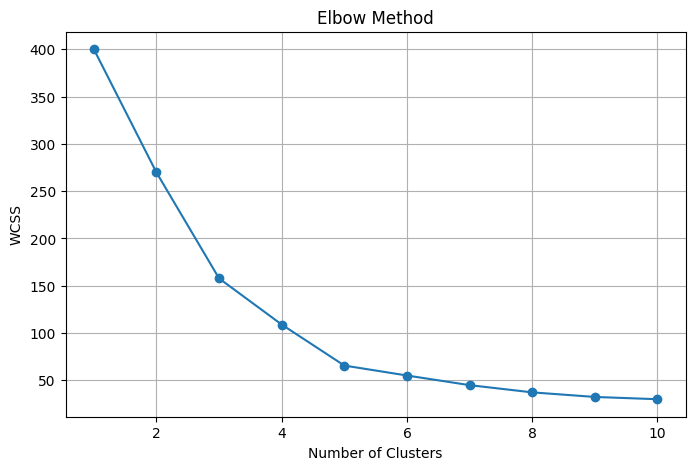


Cluster Assigned Successfully

Cluster Summary
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         86.320988  0.407407  42.716049           55.296296   
1        162.000000  0.461538  32.692308           86.538462   
2         23.090909  0.409091  25.272727           25.727273   
3        164.371429  0.542857  41.114286           88.200000   
4         23.000000  0.391304  45.217391           26.304348   

         Spending Score (1-100)  
Cluster                          
0                     49.518519  
1                     82.128205  
2                     79.363636  
3                     17.114286  
4                     20.913043  


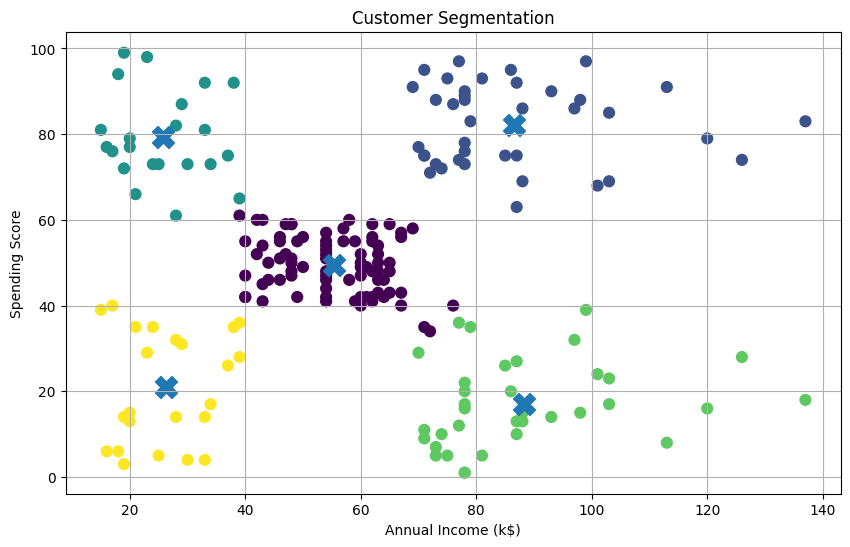


Customers per Cluster
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Output File Saved Successfully


In [1]:
# ==========================================
# DAY 4
# CUSTOMER SEGMENTATION USING K-MEANS
# ==========================================

# Step 1 : Upload Dataset

from google.colab import files

uploaded = files.upload()

# ==========================================
# Step 2 : Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ==========================================
# Step 3 : Load Dataset
# ==========================================

df = pd.read_csv("Mall_Customers.csv")

print("First 5 Records")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

# ==========================================
# Step 4 : Encode Gender
# ==========================================

df["Gender"] = df["Gender"].map({
    "Male":1,
    "Female":0
})

# ==========================================
# Step 5 : Feature Selection
# ==========================================

X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

print("\nSelected Features")
print(X.head())

# ==========================================
# Step 6 : Feature Scaling
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# Step 7 : Elbow Method
# ==========================================

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid()

plt.show()

# ==========================================
# Step 8 : K-Means Model
# ==========================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster Assigned Successfully")

# ==========================================
# Step 9 : Cluster Summary
# ==========================================

cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

print("\nCluster Summary")

print(cluster_summary)

# ==========================================
# Step 10 : Customer Segments
# ==========================================

plt.figure(figsize=(10,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=60
)

plt.scatter(
    scaler.inverse_transform(kmeans.cluster_centers_)[:,0],
    scaler.inverse_transform(kmeans.cluster_centers_)[:,1],
    s=250,
    marker='X'
)

plt.title("Customer Segmentation")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score")

plt.grid()

plt.show()

# ==========================================
# Step 11 : Customers in Each Cluster
# ==========================================

print("\nCustomers per Cluster")

print(df["Cluster"].value_counts().sort_index())

# ==========================================
# Step 12 : Save Result
# ==========================================

df.to_csv(
    "Customer_Segmentation_Output.csv",
    index=False
)

print("\nOutput File Saved Successfully")